In [116]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/Dados Comunidade (respostas) - dados.csv')

In [117]:
df.head()

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,Sim,Não,Sim,Sim,Sim,Não,34,MG,Exatas,Mais de 4 anos,Sênior,Sim
1,12/06/2025 10:59:34,Twitch,Mais que 3,Sim,Sim,Sim,Não,Não,Sim,26,MG,Exatas,Não atuo,Iniciante,Sim
2,12/06/2025 10:59:36,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Sim,39,SC,Exatas,De 1 ano a 2 anos,Júnior,Sim
3,12/06/2025 10:59:37,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Não,27,SP,Exatas,Mais de 4 anos,Pleno,Sim
4,12/06/2025 10:59:41,Twitch,2,Sim,Sim,Sim,Sim,Não,Não,29,CE,Exatas,De 1 ano a 2 anos,Pleno,Sim


#Transformando dados categóricos em dados numéricos

In [118]:
df.replace({'Sim':1,'Não':0}, inplace=True)

/tmp/ipykernel_28230/639589102.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Sim':1,'Não':0}, inplace=True)


In [119]:
pd.get_dummies(df[['Como conheceu o Téo Me Why?']]) #Get dummies transforma linhas categóricas em colunas com True ou False para cada variável. Semelhante ao pivot do Power Query.
#Útil para transformar colunas categóricas em numéricas antes de serem usadas em modelos.

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube
0,False,False,True,False,False,False,False
1,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True
4,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...
177,True,False,False,False,False,False,False
178,False,False,False,False,True,False,False
179,False,False,False,False,False,True,False
180,False,False,True,False,False,False,False


In [120]:
#Escolhendo colunas que eu vou usar o get_dummies
dummies_var = [
"Como conheceu o Téo Me Why?",
"Quantos cursos acompanhou do Téo Me Why?",
"Estado que mora atualmente",
"Área de Formação",
"Tempo que atua na área de dados",
"Posição da cadeira (senioridade)"]

num_var = [
    "Curte games?",
    "Curte futebol?",
    "Curte livros?",
    "Curte jogos de tabuleiro?",
    "Curte jogos de fórmula 1?",
    "Curte jogos de MMA?",
    "Idade"
]

In [121]:
ABT = pd.get_dummies(df[dummies_var]).astype(int) #Transformando true e false em 0 e 1. Passo as colunas que eu quero q o get_dummies seja usado

In [122]:
ABT[num_var] = df[num_var].copy()

In [123]:
ABT.head()

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Júnior,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade
0,0,0,1,0,0,0,0,1,0,0,...,0,0,1,1,0,1,1,1,0,34
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,1,1,0,0,1,26
2,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,1,1,1,1,1,39
3,0,0,0,0,0,0,1,0,0,0,...,0,1,0,1,1,1,1,1,0,27
4,0,0,0,0,1,0,0,0,0,1,...,0,1,0,1,1,1,1,0,0,29


In [124]:
ABT['Pessoa feliz'] = df["Você se considera uma pessoa feliz?"]

In [125]:
ABT

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Pessoa feliz
0,0,0,1,0,0,0,0,1,0,0,...,0,1,1,0,1,1,1,0,34,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,0,0,1,26,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,1,1,39,1
3,0,0,0,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,27,1
4,0,0,0,0,1,0,0,0,0,1,...,1,0,1,1,1,1,0,0,29,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,1,0,0,0,0,0,0,0,0,1,...,0,0,1,1,1,0,1,0,33,1
178,0,0,0,0,1,0,0,0,0,0,...,0,1,1,1,1,1,1,1,32,1
179,0,0,0,0,0,1,0,0,1,0,...,0,0,1,1,1,1,0,0,39,0
180,0,0,1,0,0,0,0,0,1,0,...,1,0,1,0,1,0,0,0,25,0


In [126]:
X = ABT.drop('Pessoa feliz', axis=1)
X.head()

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Júnior,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade
0,0,0,1,0,0,0,0,1,0,0,...,0,0,1,1,0,1,1,1,0,34
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,1,1,0,0,1,26
2,0,0,0,0,0,0,1,0,0,0,...,1,0,0,1,1,1,1,1,1,39
3,0,0,0,0,0,0,1,0,0,0,...,0,1,0,1,1,1,1,1,0,27
4,0,0,0,0,1,0,0,0,0,1,...,0,1,0,1,1,1,1,0,0,29


In [127]:
y = ABT['Pessoa feliz']
y.head()

,Pessoa feliz
0,1
1,1
2,1
3,1
4,1


In [128]:
features = ABT.columns[:-1].tolist()
print(features)

['Como conheceu o Téo Me Why?_Amigos', 'Como conheceu o Téo Me Why?_Instagram', 'Como conheceu o Téo Me Why?_LinkedIn', 'Como conheceu o Téo Me Why?_Outra rede social', 'Como conheceu o Téo Me Why?_Twitch', 'Como conheceu o Téo Me Why?_Twitter / X', 'Como conheceu o Téo Me Why?_YouTube', 'Quantos cursos acompanhou do Téo Me Why?_0', 'Quantos cursos acompanhou do Téo Me Why?_1', 'Quantos cursos acompanhou do Téo Me Why?_2', 'Quantos cursos acompanhou do Téo Me Why?_3', 'Quantos cursos acompanhou do Téo Me Why?_Mais que 3', 'Estado que mora atualmente_AM', 'Estado que mora atualmente_BA', 'Estado que mora atualmente_CE', 'Estado que mora atualmente_DF', 'Estado que mora atualmente_ES', 'Estado que mora atualmente_GO', 'Estado que mora atualmente_MA', 'Estado que mora atualmente_MG', 'Estado que mora atualmente_MT', 'Estado que mora atualmente_PA', 'Estado que mora atualmente_PB', 'Estado que mora atualmente_PE', 'Estado que mora atualmente_PR', 'Estado que mora atualmente_RJ', 'Estado qu

In [129]:
from sklearn import tree

In [130]:
tree = tree.DecisionTreeClassifier(random_state=42, min_samples_leaf=5)

tree.fit(X,y)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

#Avaliando o modelo

In [131]:
tree_predict = tree.predict(X)
tree_predict

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1])

In [132]:
df_predict = ABT[['Pessoa feliz']]

In [133]:
df_predict['tree_predict'] = tree_predict
df_predict #vendo variável verdadeira x predição do modelo

/tmp/ipykernel_28230/672325651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['tree_predict'] = tree_predict


,Pessoa feliz,tree_predict
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
177,1,1
178,1,1
179,0,0
180,0,0


#**Acurácia**

Predições corretas / Total de observações.

Formalmente:
V.N. + V.P. / V.N + F.N + V.P + F.P

In [134]:
(df_predict['Pessoa feliz'] == df_predict['tree_predict']).mean() #Colocando a porcentagem que meu modelo está acertando a predição

np.float64(0.8626373626373627)

Com isso, não conseguimos ver aonde o nosso modelo está errando ou acertando mais. Só temos uma média de acertos, mas poderiamos ter erro alto em classificar uma determinada classe.

Outro exemplo, é um modelo que acerta 90% das predições em um dataset onde um das classes é bem menor que a outra. Exemplo: Tenho um dataset com 2% da classe A e 98% da classe B. Se o modelo acertar TODAS as predições para a classe B, eu tenho 98% de acertos, mesmo errando todas as outras classificações.

Para contornarmos isso, usamos o que é chamado de **Matriz de confusão**

#**Matriz de confusão**

Essa matriz me mostra nas linhas o valor real (observado), e nas colunas tenho a predição do meu modelo.

Nesse exemplo, podemos ver que de 35 feliz = 0 observados (somo a linha toda de pessoa feliz = 0 para saber o total), o meu modelo preveu o 0 e acertou 16 vezes, e errou 6 vezes prevendo 1.

Já para feliz = 1 com total de 147, o meu modelo preveu errado 19 vezes feliz = 0, e acertou 141 vezes.

In [135]:
pd.crosstab(df_predict['Pessoa feliz'], df_predict['tree_predict'])

tree_predict,0,1
Pessoa feliz,,
0,16,19
1,6,141


Quando meu modelo prevê um valor negativo (0) para uma observação de fato negativa (0), temos o que chamamos de Verdadeiro Negativo.
Quando meu modelo prevê um valor positivo (1) para uma observação que de fato é positiva, temos o que chamamos de Verdadeiro Positivo.

Agora, quando meu modelo prevê um valor positivo para uma observação negativa, temos um Falso Negativo.
O contrário, previsão negativa para um valor positivo, é chamado de Falso Positivo.

Saber o tipo de erro que o modelo tem, pode ajudar não só a melhorar a acurácia do modelo, mas também entender o tipo de erro estátistico (Erro I ou Erro II)

#**Precisão**

% de vezes que a observação de classe = y é a mesma prevista pelo modelo, dentro de TODAS as predições do modelo para classe = y (Estando certas ou erradas).

Acertos de classe y / Todas as predições de classe y

Precisão = V.P. / V.P. + F.P.

#**Recall**

% de casos reais de classe y = 1 que o modelo conseguiu capturar.

Útil para entender a taxa de acerto para classes que acontecem poucas vezes ou para classes que só um valor nos interessa, como Fraudes, que tendem a compor uma pequena % das transações.
Com isso, podemos escolher a melhor abordagem para a classificação do modelo, pois é preferível que modelos de fraudes capturem todas as transações fraudulentas mesmo que capture algumas transações normais. Com isso, escolhemos o  Erro Tipo 1, classificando mais Falsos Positivos, em troca de conseguirmos classificar mais Verdadeiros Positivos

As vezes tenho que abrir mão da precisão para aumentar o recall de uma classe, ou abrir mão do recall para aumentar a precisão. Qual será o nosso sacrifício dependerá de qual o nosso problema.

Acertos de predição da classe y = 1 / Observações de y

Recall = VP / FN + VP

Quanto mais perto de 1, melhor.

#**Especificidade**

Contrário do recall, informa a % que o modelo capturou classe y = 0 dentro das observações reais.

Acertos de predição da classe y = 0 / Observações de y

Especificidade = VN / VN + VP

Quanto mais perto de 0, melhor.

#**Curva ROC (AUC)**

Sensibilidade (Recall) vs Especificidade. Ajustando o ponto de corte do modelo com base na probabilidade de classificar uma observação como y = 1, eu posso alterar a acurácia, precisão,
recall e especifificidade do modelo. Essa alteração no ponto de corte aumenta uma métrica enquanto diminui outra, exemplo: Aumentar o ponto de corte da predição para 0.8, aumenta
a precisão e especificidade do modelo, porém diminui o meu recall.
A curva ROC é a especificidade e recall para cada ponto de corte do meu modelo, me dando a informação se meu modelo está, com a mudança do ponto de corte para minhas classes, prevendo cada vez melhor ambas as classes.

Para cada ponto de corte do nosso modelo:
 1. Eixo x: 1 - especificidade
 2. Eixo y: Recall

Depois de traçar a curva, temos a área preenchida (ou área abaixo da linha) pelo modelo para todos os pontos de corte. O modelo AUC ideal cobre todo o gráfico 1x1 (Linha que começa em 0 sobe o eixo y até 1 verticalmente e reta, e ao chegar em y =1, muda para reta horizontalmente em direção a x = 1, cobrindo todo o gráfico). Um bom sinal que nosso modelo está bem, é o eixo y aumentar bem mais rápido que o eixo x. Quanto mais perto de y = 1 e x=0 simultaneamente para todos os pontos de corte, melhor está nosso AUC.

**Essas métricas nos dão noção de como o nosso modelo performa em cada aspecto e referente a cada classe, nos dando uma base do custo que ele pode ter para um determinado negócio. Abrir mão de uma métrica ou outra para um modelo, depende completamente do por que aquele modelo está sendo criado e qual o meu objetivo com ele.**

#**Usando as métricas no nosso modelo**

In [136]:
df_predict['tree_proba'] = tree.predict_proba(X)[:,1] #Colocando a probabilidade para cada classificação no meu dataframe

/tmp/ipykernel_28230/3807707626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['tree_proba'] = tree.predict_proba(X)[:,1] #Colocando a probabilidade para cada classificação no meu dataframe


In [137]:
df_predict.head(5)

,Pessoa feliz,tree_predict,tree_proba
0,1,1,0.714286
1,1,1,0.750000
2,1,1,0.857143
3,1,1,0.857143
4,1,1,1.000000


In [138]:
from sklearn import metrics

**Acurácia do modelo**

In [139]:
tree_acc = metrics.accuracy_score(df_predict['Pessoa feliz'], df_predict['tree_predict'])
tree_acc

0.8626373626373627

**Precisão do modelo**

In [140]:
tree_precision = metrics.precision_score(df_predict['Pessoa feliz'], df_predict['tree_predict'])
tree_precision

0.88125

**Recall**

In [141]:
tree_recall = metrics.recall_score(df_predict['Pessoa feliz'], df_predict['tree_predict'])
tree_recall

0.9591836734693877

**Especificidade**

In [142]:
tree_specificity = metrics.recall_score(df_predict['Pessoa feliz'], df_predict['tree_predict'], pos_label=0) #funciona se minha classe nega-
#tiva for 0

tree_specificity

0.45714285714285713

**Curva roc**

In [143]:
tree_roc = metrics.roc_curve(df_predict['Pessoa feliz'], df_predict['tree_proba'])
tree_auc = metrics.roc_auc_score(df_predict['Pessoa feliz'], df_predict['tree_proba']) #Auc diz a respeito da área preenchida pela nossa curva ROC
print("Tree auc: ",tree_auc)

Tree auc:  0.9091350826044703


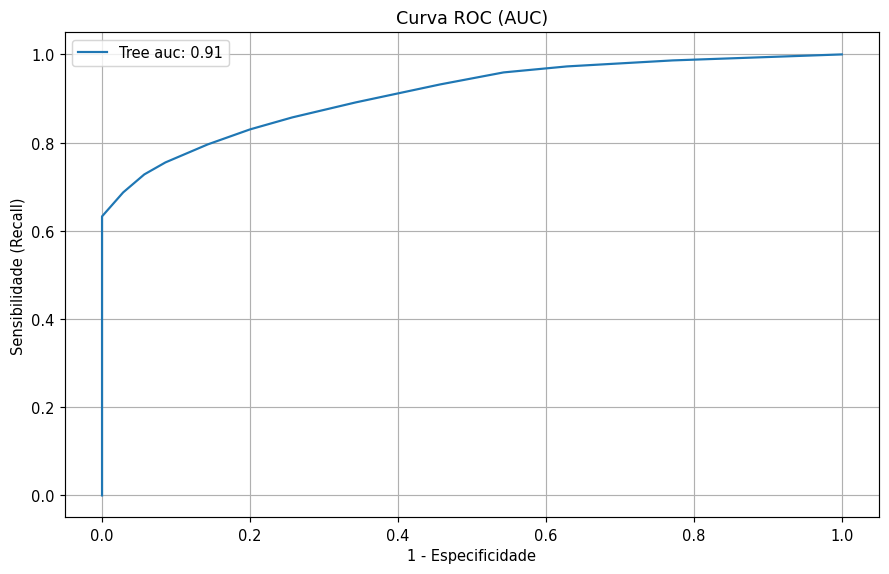

In [144]:
plt.figure(dpi=(105), figsize=(10,6))
plt.plot(tree_roc[0], tree_roc[1])
plt.grid(True)
plt.title("Curva ROC (AUC)")
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade (Recall)")
plt.legend([f'Tree auc: {tree_auc:.2f}'])

**Comparando com outro modelo**

In [145]:
from sklearn import naive_bayes

In [146]:
nb = naive_bayes.GaussianNB()

In [147]:
nb.fit(X,y)

GaussianNB()

In [148]:
df_predict['nb_predict'] = nb.predict(X)

/tmp/ipykernel_28230/2150586988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['nb_predict'] = nb.predict(X).copy()


In [149]:
df_predict['nb_proba'] = nb.predict_proba(X)[:,1]

/tmp/ipykernel_28230/1424781399.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['nb_proba'] = nb.predict_proba(X)[:,1].copy()


In [150]:
df_predict.head(5)

,Pessoa feliz,tree_predict,tree_proba,nb_predict,nb_proba
0,1,1,0.714286,0,8.579697e-18
1,1,1,0.750000,0,2.420248e-19
2,1,1,0.857143,0,3.280598e-10
3,1,1,0.857143,0,8.082140e-12
4,1,1,1.000000,1,1.000000e+00


In [152]:
nb_acc = metrics.accuracy_score(df_predict['Pessoa feliz'], df_predict['nb_predict'])
nb_precision = metrics.precision_score(df_predict['Pessoa feliz'], df_predict['nb_predict'])
nb_recall = metrics.recall_score(df_predict['Pessoa feliz'], df_predict['nb_predict'])
nb_specificity = metrics.recall_score(df_predict['Pessoa feliz'], df_predict['nb_predict'], pos_label=0)
nb_roc = metrics.roc_curve(df_predict['Pessoa feliz'], df_predict['nb_proba'])
nb_auc = metrics.roc_auc_score(df_predict['Pessoa feliz'], df_predict['nb_proba'])
nb_auc

np.float64(0.8165208940719145)

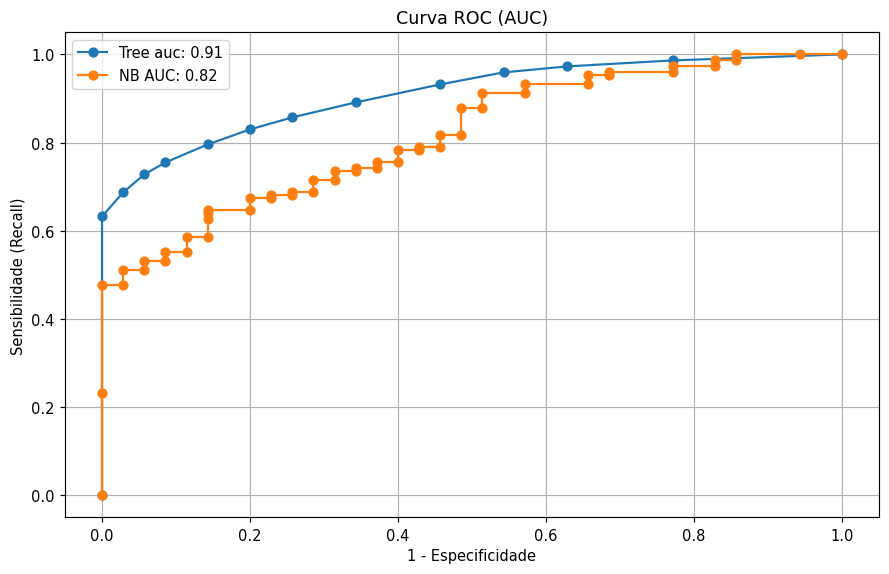

In [155]:
plt.figure(dpi=(105), figsize=(10,6))
plt.plot(tree_roc[0], tree_roc[1], 'o-') #cada bolinha é um ponto de corte
plt.plot(nb_roc[0], nb_roc[1], 'o-')
plt.grid(True)
plt.title("Curva ROC (AUC)")
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade (Recall)")
plt.legend([f'Tree auc: {tree_auc:.2f}',f'NB AUC: {nb_auc:.2f}'])

In [156]:
from sklearn import linear_model

In [162]:
reg_log = linear_model.LogisticRegression(penalty=None, fit_intercept=True)
reg_log.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(penalty=None)

In [165]:
df_predict['rl_predict'] = reg_log.predict(X)

/tmp/ipykernel_28230/1555662064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['rl_predict'] = reg_log.predict(X)


In [166]:
df_predict['rl_proba'] = reg_log.predict_proba(X)[:,1]

/tmp/ipykernel_28230/1748020512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predict['rl_proba'] = reg_log.predict_proba(X)[:,1]


In [167]:
rl_acc = metrics.accuracy_score(df_predict['Pessoa feliz'], df_predict['rl_predict'])
rl_precision = metrics.precision_score(df_predict['Pessoa feliz'], df_predict['rl_predict'])
rl_recall = metrics.recall_score(df_predict['Pessoa feliz'], df_predict['rl_predict'])
rl_specificity = metrics.recall_score(df_predict['Pessoa feliz'], df_predict['rl_predict'], pos_label=0)
rl_roc = metrics.roc_curve(df_predict['Pessoa feliz'], df_predict['rl_proba'])
rl_auc = metrics.roc_auc_score(df_predict['Pessoa feliz'], df_predict['rl_proba'])
rl_auc

np.float64(0.8837706511175899)

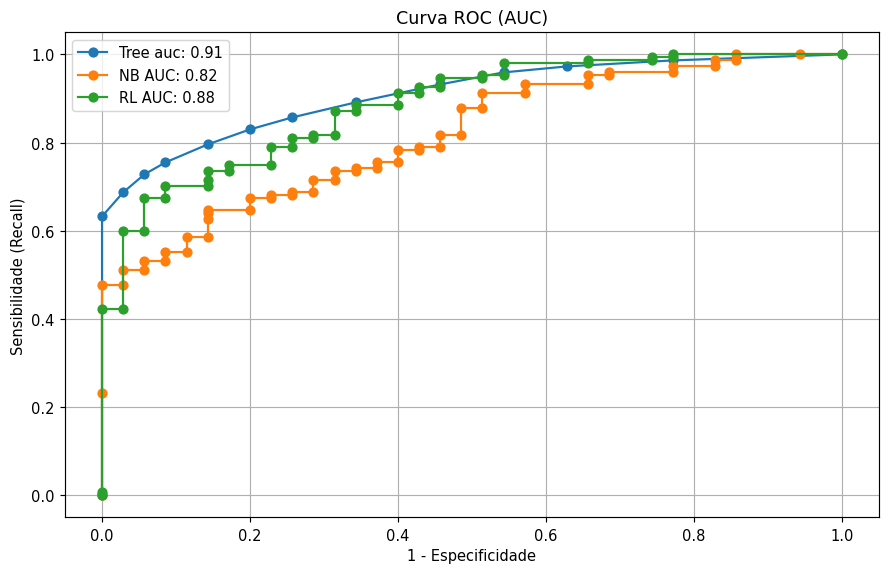

In [168]:
plt.figure(dpi=(105), figsize=(10,6))
plt.plot(tree_roc[0], tree_roc[1], 'o-') #cada bolinha é um ponto de corte
plt.plot(nb_roc[0], nb_roc[1], 'o-')
plt.plot(rl_roc[0], rl_roc[1], 'o-')
plt.grid(True)
plt.title("Curva ROC (AUC)")
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade (Recall)")
plt.legend([f'Tree auc: {tree_auc:.2f}',f'NB AUC: {nb_auc:.2f}',f'RL AUC: {rl_auc:.2f}'])

A curva ROC anda na probabilidade do modelo, e não me mostra somente um recorte específico. Por isso é uma métrica útil para modelos